# A1: Car Price Prediction
**Name:** Lin Htet Aung

## 1. Imports; Load Data

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import sklearn

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy: 2.5.2
pandas: 3.0.5
seaborn: 0.13.2
Matplotlib: 3.11.1
scikit-learn: 1.9.0


In [20]:
# Load data
df = pd.read_csv("../data/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [21]:
# Get info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [22]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Note: At this stage, we uploaded libraries and data.\
We also know how many data inside (8128 entries, 13 columns).\
And some Statistical Info.

## 2. Data Cleaning

In [23]:
# Before we do anything, I want to check nulls and duplicates first
print("Original shape:", df.shape)
print("Original missing values:")
display(df.isnull().sum())

print("Original exact duplicates:", df.duplicated().sum())

Original shape: (8128, 13)
Original missing values:


name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Original exact duplicates: 1202


In [24]:
# As per instructions, we do these steps

# Remove fuel types that use a different mileage unit
df = df.loc[~df["fuel"].isin(["CNG", "LPG"])].copy()

# Map the remaining ordered owner categories
owner_mapping = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}
df["owner"] = df["owner"].map(owner_mapping)

# Extract numbers from these column units, invalid or missing strings become NaN.
for column in ["mileage", "engine", "max_power"]:
    df[column] = pd.to_numeric(
        df[column]
        .astype("string")
        .str.extract(
            r"([-+]?\d*\.?\d+)",
            expand=False
        ),
        errors="coerce"
    )

# Rename "name" to "brand" and get only first word
df.rename(columns={'name': 'brand'},inplace=True)
df["brand"] = df["brand"].str.split().str[0]

# Drop unwanted columns
df = df.drop(columns=["torque"])


In [25]:
display(df.head(10))

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.4,1248,74.0,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.7,1497,78.0,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.0,1396,90.0,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.1,1298,88.2,5.0
5,Hyundai,2017,440000,45000,Petrol,Individual,Manual,1,20.14,1197,81.86,5.0
7,Maruti,2001,45000,5000,Petrol,Individual,Manual,2,16.1,796,37.0,4.0
8,Toyota,2011,350000,90000,Diesel,Individual,Manual,1,23.59,1364,67.1,5.0
9,Ford,2013,200000,169000,Diesel,Individual,Manual,1,20.0,1399,68.1,5.0
10,Renault,2014,500000,68000,Diesel,Individual,Manual,2,19.01,1461,108.45,5.0


In [ ]:
# Let's see what is wrong with Test Drive Cars(coded as 5)
display(df[df['owner'] == 5])


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
4383,Volkswagen,2019,1350000,5400,Diesel,Dealer,Manual,5,22.27,1498,108.6,5.0
4950,Audi,2019,6223000,7800,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4951,Audi,2019,5923000,11500,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
4952,Audi,2019,6523000,23600,Petrol,Dealer,Automatic,5,15.26,1798,187.74,5.0
6220,Honda,2019,2000000,24857,Petrol,Dealer,Automatic,5,16.5,1799,139.46,5.0


In [ ]:
# Wow, they are really expensive
# We will delete them as per instruction
df = df.loc[df["owner"] != "Test Drive Car"].copy()


DF Shape after instructions:  (8033, 12)


In [29]:
# After done as per instructions, we will check nulls and duplicates again
print("After instructions")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After instructions
Shape: (8033, 12)
Missing values:


brand              0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          214
engine           214
max_power        208
seats            214
dtype: int64

Exact duplicates: 1220


In [31]:
# We will look at null values and see if we should impute or delete rows

required_columns = ["mileage", "engine", "max_power", "seats"]

missing_mask = df[required_columns].isnull().any(axis=1)
null_rows_df = df.loc[missing_mask].copy()

print("Rows with missing required values:", len(null_rows_df))
print(f"Percentage affected: {missing_mask.mean() * 100:.2f}%")

display(
    null_rows_df[
        required_columns
        + ["brand", "year", "selling_price"]
    ].head(10)
)

Rows with missing required values: 214
Percentage affected: 2.66%


,mileage,engine,max_power,seats,brand,year,selling_price
13,<NA>,<NA>,<NA>,NaN,Maruti,2007,200000
31,<NA>,<NA>,<NA>,NaN,Fiat,2003,70000
78,<NA>,<NA>,<NA>,NaN,Tata,2003,50000
87,<NA>,<NA>,<NA>,NaN,Maruti,2015,475000
119,<NA>,<NA>,<NA>,NaN,Maruti,2010,300000
138,<NA>,<NA>,<NA>,NaN,BMW,2017,2150000
200,<NA>,<NA>,<NA>,NaN,Toyota,2012,235000
206,<NA>,<NA>,<NA>,NaN,Maruti,2003,40000
228,<NA>,<NA>,<NA>,NaN,Maruti,2008,130000
252,<NA>,<NA>,<NA>,NaN,Tata,2005,75000


In [32]:
# As we see, those null values are happening in the same rows.
# And the percentage is very small too, so we will delete those rows.'
df = (
    df.loc[~missing_mask]
    .copy()
    .reset_index(drop=True)
)

In [34]:
# After deleting rows with missing values
print("After deleting nulls:")
print("Shape:", df.shape)
print("Missing values:")
display(df.isnull().sum())

print("Exact duplicates:", df.duplicated().sum())

After deleting nulls:
Shape: (7819, 12)
Missing values:


brand            0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

Exact duplicates: 1207


In [ ]:
# Now we will see duplicated rows

# "keep= False" means include first occurance
duplicate_rows_df = df.loc[df.duplicated(keep=False)].copy()

print("Rows involved in duplicate groups:", len(duplicate_rows_df))
print("Duplicate copies to remove:", df.duplicated().sum())

display(
    duplicate_rows_df
    .sort_values(by=list(df.columns))
    .head(10)
)

Rows involved in duplicate groups: 1831
Duplicate copies to remove: 1207


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2051,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
7472,Audi,2014,1850000,76131,Diesel,Individual,Automatic,1,13.22,2967,241.4,5.0
1905,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
7040,Audi,2017,2825000,22000,Diesel,Dealer,Automatic,1,15.73,1968,174.33,5.0
123,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1502,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
1791,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
3100,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
5044,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0
7399,Audi,2018,3975000,31800,Diesel,Dealer,Automatic,1,17.01,1968,188.0,5.0


Note: Since we only use the first word from "name",\
we may have more duplicates after doing as instructed.

In [36]:
# Delete all those duplicates
df = (
    df.drop_duplicates()
    .reset_index(drop=True)
    .copy()
)

In [37]:
# After deleting duplicated rows
print("After deleting duplicates:")
print("Shape:", df.shape)
print("Exact duplicates:", df.duplicated().sum())

After deleting duplicates:
Shape: (6612, 12)
Exact duplicates: 0


### What we had done: 
- Load original data
- inspect shape, types, missing counts and duplicates
- map owner values
- remove CNG and LPG
- parse mileage
- parse engine
- parse max_power
- extract brand from name
- remove Test Drive Car rows
- drop torque
- inspect missing rows in final retained features
- remove missing rows
- inspect exact duplicates
- remove exact duplicates

## 3. EDA

In [40]:
# Set theme for plot
sns.set_theme(style="whitegrid", context="notebook")

In [38]:
# We will use log function for selling price because it is too big 

df["selling_price_log"] = np.log(df["selling_price"])

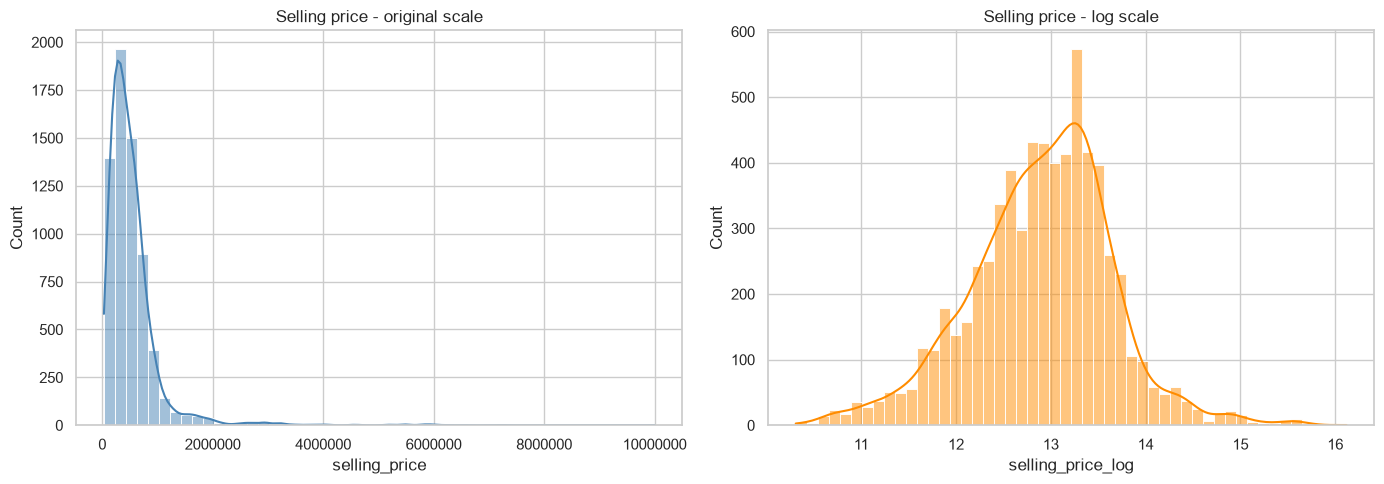

In [ ]:
# To show side by side the difference between original selling price and it's log form

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Selling price - original scale")
axes[0].ticklabel_format(style="plain", axis="x")
sns.histplot(df["selling_price_log"], bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Selling price - log scale")
plt.tight_layout()
plt.show()

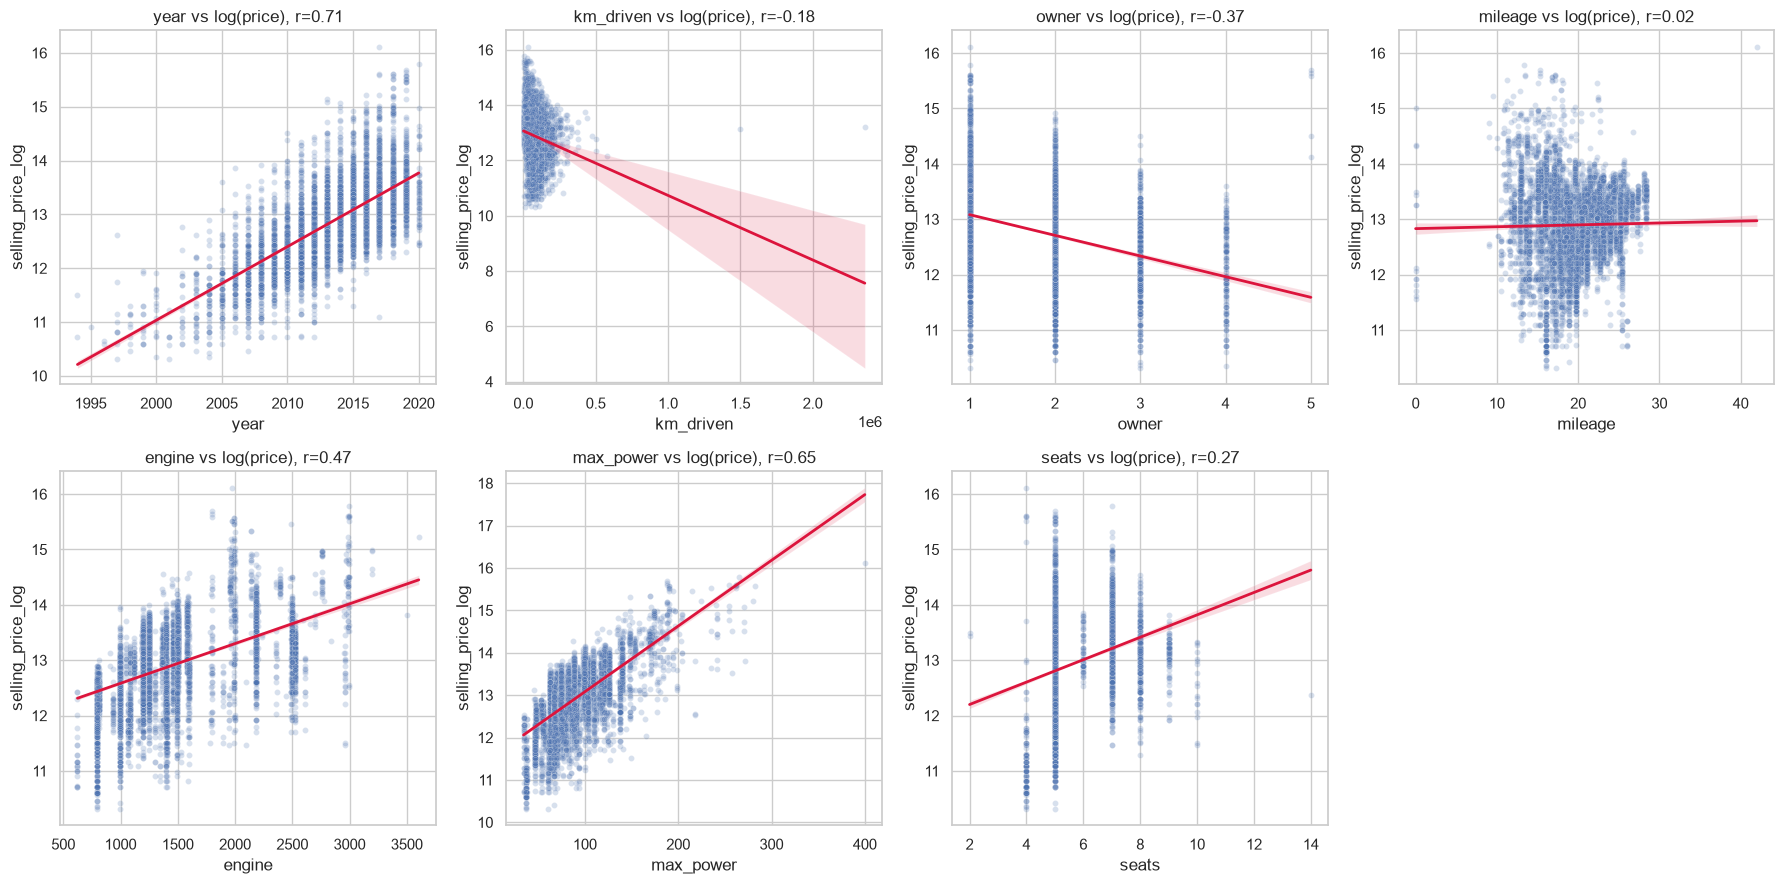

In [ ]:
# Scatter and regression plots for numeric features with selling_price_log

numeric_features = ["year", "km_driven", "owner", "mileage", "engine", "max_power", "seats"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, column in zip(axes.flat, numeric_features):
    sns.scatterplot(data=df, x=column, y="selling_price_log", alpha=0.22, s=18, ax=ax)
    sns.regplot(data=df, x=column, y="selling_price_log", scatter=False,
                color="crimson", line_kws={"linewidth": 2}, ax=ax)
    corr = df[column].corr(df["selling_price_log"])
    ax.set_title(f"{column} vs log(price), r={corr:.2f}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

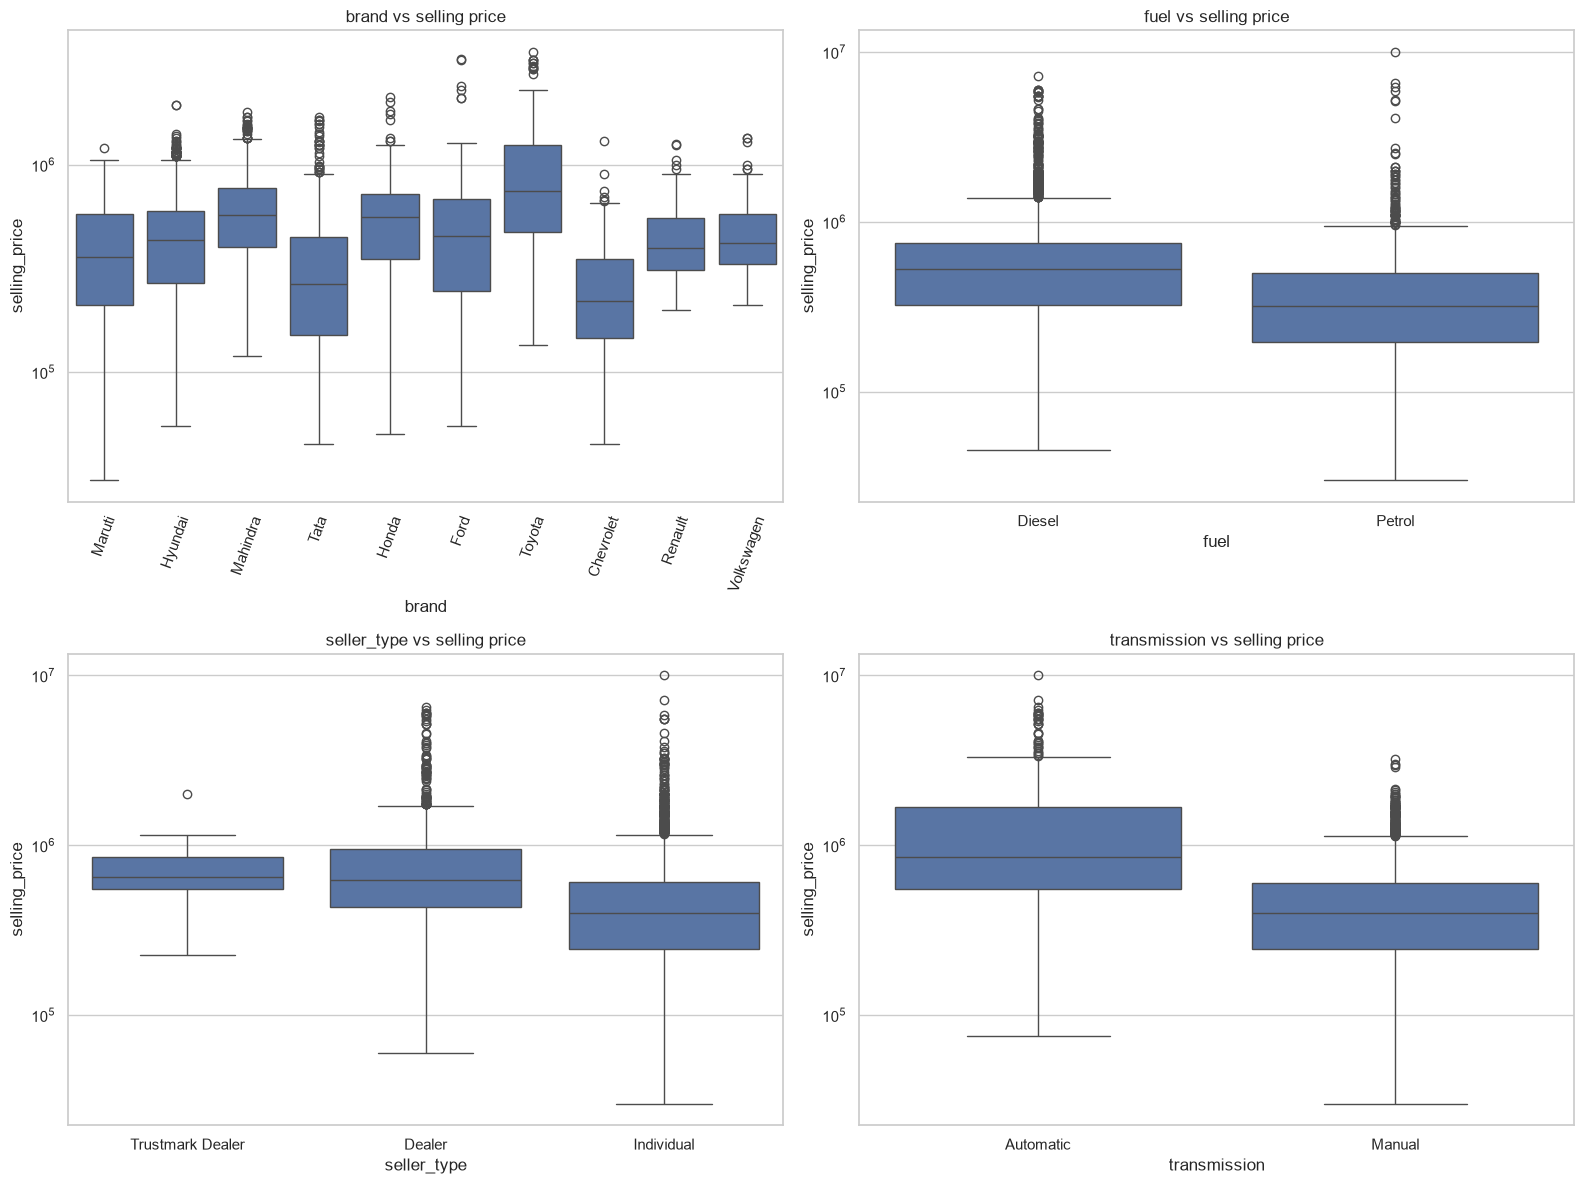

In [ ]:
# Box plots for categorical features with selling_price

categorical_features = ["brand", "fuel", "seller_type", "transmission"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, categorical_features):
    if column == "brand":
        # Select the 10 brands with the most observations 
        order = df['brand'].value_counts().index[:10].tolist()
        # To order by median price range
        # order = df.groupby(column)["selling_price"].median().sort_values(ascending=False).index[:10]
        plot_data = df.loc[df[column].isin(order)]
    else:
        order = df.groupby(column)["selling_price"].median().sort_values(ascending=False).index
        plot_data = df
    sns.boxplot(data=plot_data, x=column, y="selling_price", order=order, ax=ax)
    
    # Prices remain in original units, only the visual spacing is logarithmic
    ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=70 if column == "brand" else 0)
    ax.set_title(f"{column} vs selling price")
plt.tight_layout()
plt.show()

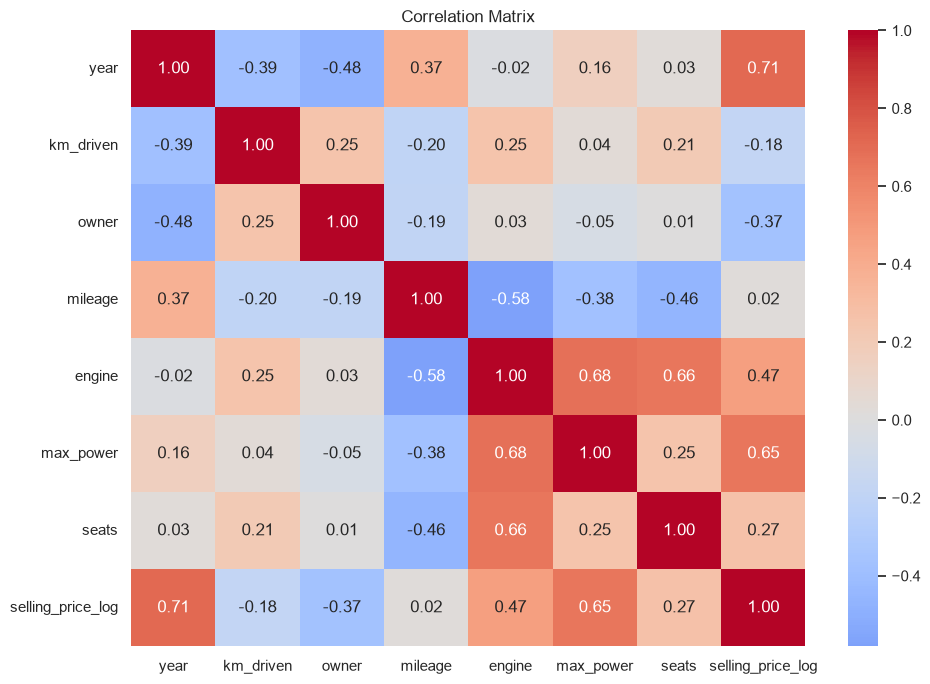

In [53]:
# Checking out heatmap

corr = df[numeric_features + ["selling_price_log"]].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [51]:
# Copy cleaned data for correlation analysis
heatmap_df = df.copy()

# One-hot encode nominal categorical features
heatmap_df = pd.get_dummies(
    heatmap_df,
    columns=[
        "brand",
        "fuel",
        "seller_type",
        "transmission"
    ],
    dtype=int
)

# Remove the original target
heatmap_df = heatmap_df.drop(columns="selling_price")

# Calculate correlations with the log-transformed target
target_correlations = (
    heatmap_df
    .corr(numeric_only=True)["selling_price_log"]
    .drop("selling_price_log")
    .sort_values(key=abs, ascending=False)
)

# Display correlations
display(target_correlations.to_frame("correlation"))

,correlation
year,0.710194
max_power,0.654450
engine,0.471563
owner,-0.366443
transmission_Automatic,0.355387
transmission_Manual,-0.355387
fuel_Diesel,0.349599
fuel_Petrol,-0.349599
seats,0.265938
seller_type_Individual,-0.236446


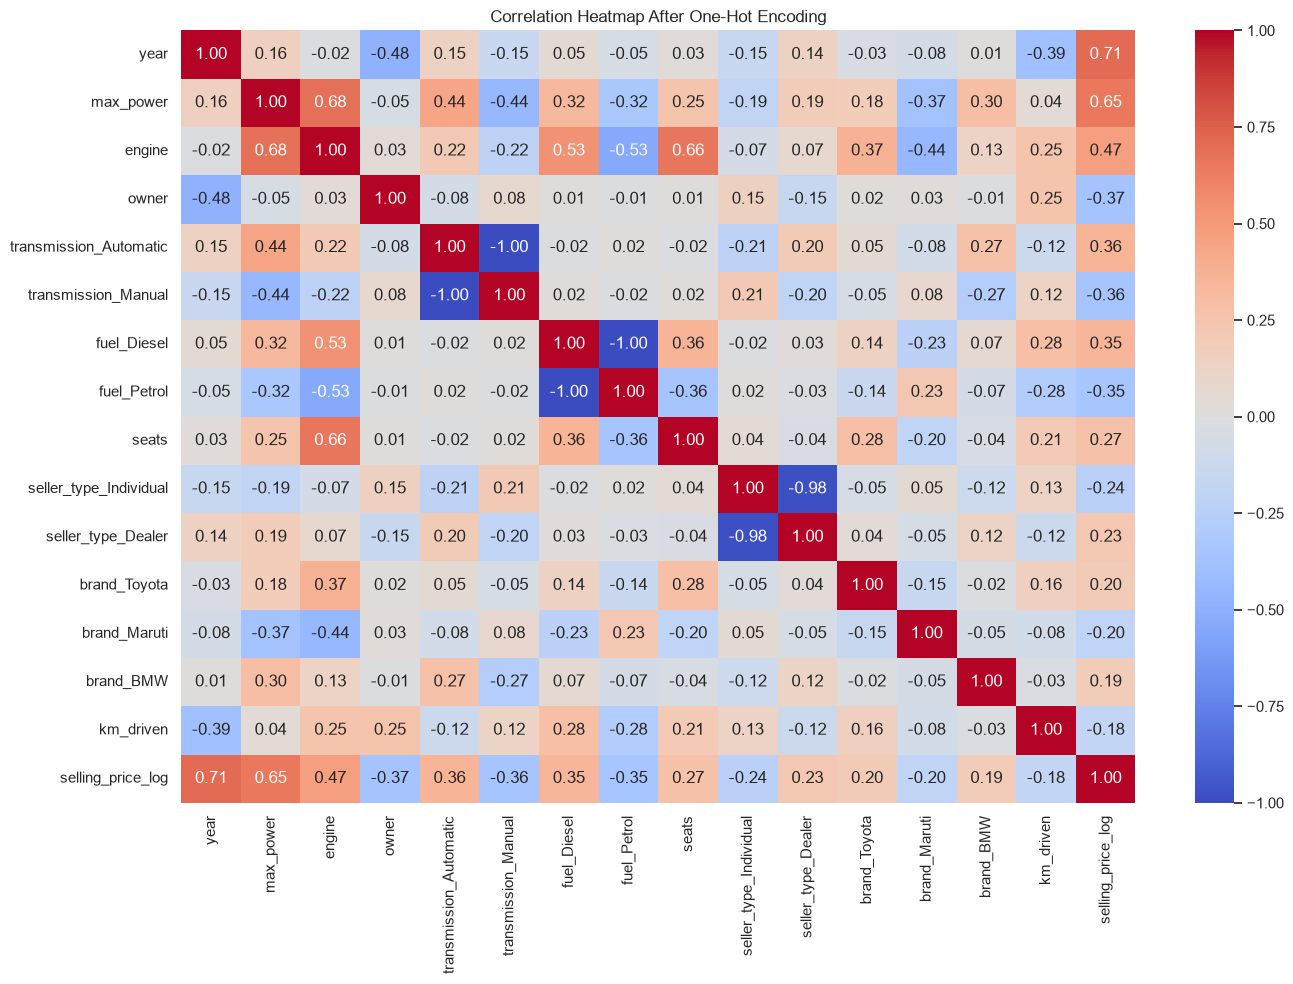

In [52]:
top_feature_names = target_correlations.head(15).index.tolist()

plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_df[
        top_feature_names + ["selling_price_log"]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap After One-Hot Encoding")
plt.tight_layout()
plt.show()

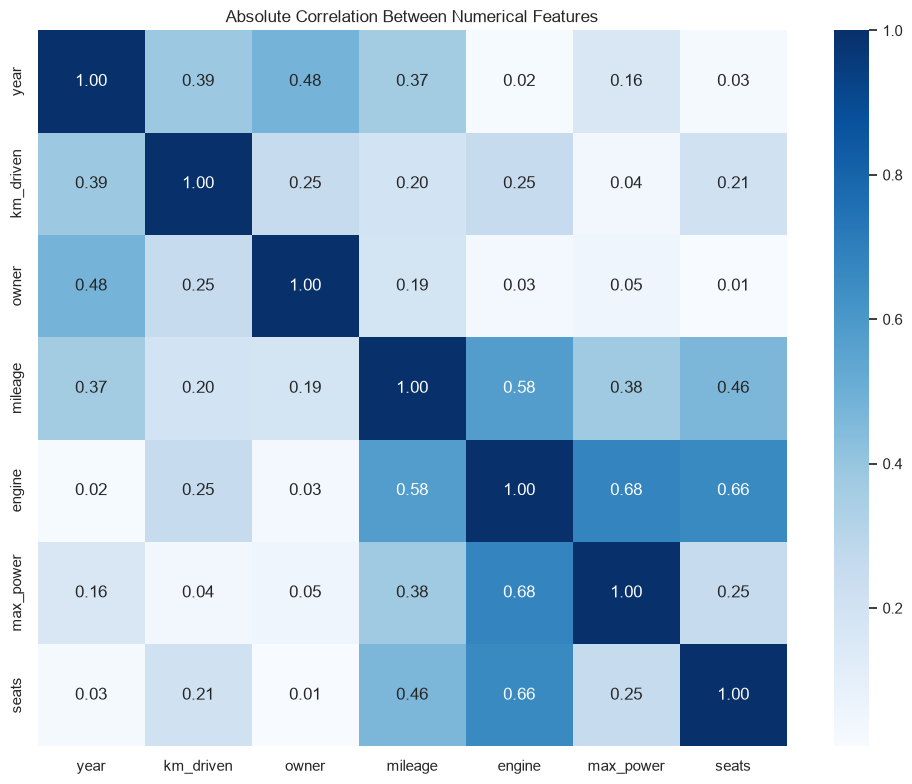

In [ ]:


feature_correlation = (df[numeric_features].corr().abs())

plt.figure(figsize=(10, 8))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Absolute Correlation Between Numerical Features")

plt.tight_layout()
plt.show()

### EDA observations

- Log transformation makes the highly right-skewed target substantially more symmetric and reduces the influence of extremely expensive cars.
- Newer model year and greater maximum power generally have positive relationships with selling price; kilometers driven and owner number tend to have negative relationships.
-  No additional predictors were removed solely based on the correlation heatmap. Although some numerical features, particularly engine capacity and maximum power, exhibited correlation with one another, they represent different vehicle characteristics and may provide complementary information to nonlinear models. Features with low marginal correlation were also retained because Pearson correlation only measures linear relationships.

## 4. Train-Test Split

In [ ]:
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

RANDOM_STATE = 42
TEST_SIZE = 0.20

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)

In [68]:
X = df.drop(columns=["selling_price", "selling_price_log"])

y_price = df["selling_price_log"]


In [70]:
X_train, X_test, y_train_price, y_test_price = train_test_split(
    X,
    y_price,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train_price:", y_train_price.shape)
print("y_test_price:", y_test_price.shape)

X_train: (5289, 11)
X_test: (1323, 11)
y_train_price: (5289,)
y_test_price: (1323,)


## 5. Preprocessing

In [71]:
numeric_columns = ["year", "km_driven", "owner", "mileage", "engine", "max_power", "seats"]
categorical_columns = ["brand", "fuel", "seller_type", "transmission"]

numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessing, numeric_columns),
    ("categorical", categorical_preprocessing, categorical_columns),
], remainder="drop")

print("Numeric features:", numeric_columns)
print("Categorical features:", categorical_columns)

Numeric features: ['year', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['brand', 'fuel', 'seller_type', 'transmission']


Note: The pipelines learn imputation and one-hot encoding from training data only. During cross-validation, each fold fits its own preprocessing values, preventing data leakage.

## 6. Modeling

In [ ]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy median": DummyRegressor(strategy="median"),
    "Linear regression": LinearRegression(),
    "Support vector regression": SVR(kernel="rbf", C=10.0, epsilon=0.1),
    "K-nearest neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision tree": DecisionTreeRegressor(
        max_depth=12, min_samples_leaf=4, random_state=RANDOM_STATE
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=100, n_jobs=1, random_state=RANDOM_STATE
    ),
}

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

cv_rows = []
for name, estimator in models.items():
    pipeline = Pipeline([("preprocessor", clone(preprocessor)), ("model", estimator)])
    scores = cross_validate(
        pipeline, X_train, y_train_price, cv=CV, scoring=scoring,
        n_jobs=-1, return_train_score=False,
    )
    cv_rows.append({
        "model": name,
        "CV MAE log": -scores["test_mae"].mean(),
        "CV RMSE log": -scores["test_rmse"].mean(),
        "CV R2": scores["test_r2"].mean(),
        "CV R2 std": scores["test_r2"].std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV RMSE log").reset_index(drop=True)
display(cv_results.round({
    "CV MAE log": 4, "CV RMSE log": 4,
    "CV R2": 4, "CV R2 std": 4,
}))

,model,CV MAE log,CV RMSE log,CV R2,CV R2 std
0,Random forest,0.1671,0.2299,0.9064,0.0057
1,Support vector regression,0.1699,0.2327,0.9041,0.0081
2,Linear regression,0.1944,0.2545,0.8851,0.0104
3,K-nearest neighbors,0.1939,0.2616,0.8787,0.0073
4,Decision tree,0.1914,0.2661,0.8743,0.0126
5,Dummy median,0.5828,0.7554,-0.0083,0.0067


Note: Models are compared only on the training partition. MAE and RMSE are calculated on the log target during cross-validation; lower values are better. The dummy model establishes the minimum useful baseline.\
According to the score, Random Forest is the best.

## 7. Random Forest Grid Search

In [79]:
rf_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])

param_grid = {
    "model__bootstrap": [True],
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=CV,
    n_jobs=-1,
    return_train_score=True,
    refit=True,
)
grid_search.fit(X_train, y_train_price)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated log-MSE: {-grid_search.best_score_:.4f}")
print(f"Best cross-validated log-RMSE: {np.sqrt(-grid_search.best_score_):.4f}")

grid_results = pd.DataFrame(grid_search.cv_results_)
display(
    grid_results[["params", "mean_train_score", "mean_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
)

Best parameters: {'model__bootstrap': True, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Best cross-validated log-MSE: 0.0514
Best cross-validated log-RMSE: 0.2267


,params,mean_train_score,mean_test_score,rank_test_score
7,"{'model__bootstrap': True, 'model__max_depth':...",-0.015909,-0.051389,1
11,"{'model__bootstrap': True, 'model__max_depth':...",-0.015881,-0.051391,2
10,"{'model__bootstrap': True, 'model__max_depth':...",-0.016051,-0.051691,3
6,"{'model__bootstrap': True, 'model__max_depth':...",-0.016075,-0.051715,4
5,"{'model__bootstrap': True, 'model__max_depth':...",-0.007959,-0.052431,5
9,"{'model__bootstrap': True, 'model__max_depth':...",-0.007797,-0.052499,6
3,"{'model__bootstrap': True, 'model__max_depth':...",-0.027093,-0.052705,7
1,"{'model__bootstrap': True, 'model__max_depth':...",-0.024216,-0.052728,8
4,"{'model__bootstrap': True, 'model__max_depth':...",-0.008151,-0.052839,9
2,"{'model__bootstrap': True, 'model__max_depth':...",-0.027256,-0.052856,10


## 8. Testing

In [80]:
final_pipeline = grid_search.best_estimator_

pred_log = final_pipeline.predict(X_test)
pred_price = np.exp(pred_log) 
actual_price = np.exp(y_test_price)

test_metrics = pd.Series({
    "MSE (price units squared)": mean_squared_error(actual_price, pred_price),
    "MAE (price units)": mean_absolute_error(actual_price, pred_price),
    "RMSE (price units)": mean_squared_error(actual_price, pred_price) ** 0.5,
    "R2 (price units)": r2_score(actual_price, pred_price),
    "MSE (log price)": mean_squared_error(y_test_price, pred_log),
    "MAE (log price)": mean_absolute_error(y_test_price, pred_log),
    "RMSE (log price)": mean_squared_error(y_test_price, pred_log) ** 0.5,
    "R2 (log price)": r2_score(y_test_price, pred_log),
})
display(test_metrics.to_frame("value").round(4))

,value
MSE (price units squared),1.611457e+10
MAE (price units),7.169253e+04
RMSE (price units),1.269432e+05
R2 (price units),9.342000e-01
MSE (log price),4.070000e-02
MAE (log price),1.475000e-01
RMSE (log price),2.017000e-01
R2 (log price),9.272000e-01


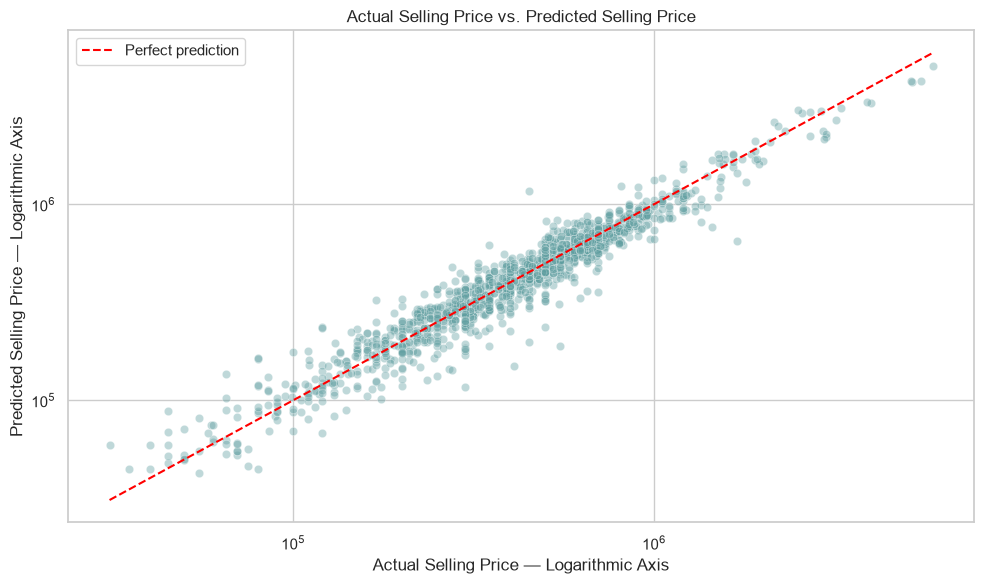

In [81]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=actual_price,
    y=pred_price,
    alpha=0.4,
    color="cadetblue"
)

minimum_price = min(
    actual_price.min(),
    pred_price.min()
)

maximum_price = max(
    actual_price.max(),
    pred_price.max()
)

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Actual Selling Price vs. Predicted Selling Price"
)

plt.xlabel(
    "Actual Selling Price — Logarithmic Axis"
)

plt.ylabel(
    "Predicted Selling Price — Logarithmic Axis"
)

plt.legend()
plt.tight_layout()
plt.show()

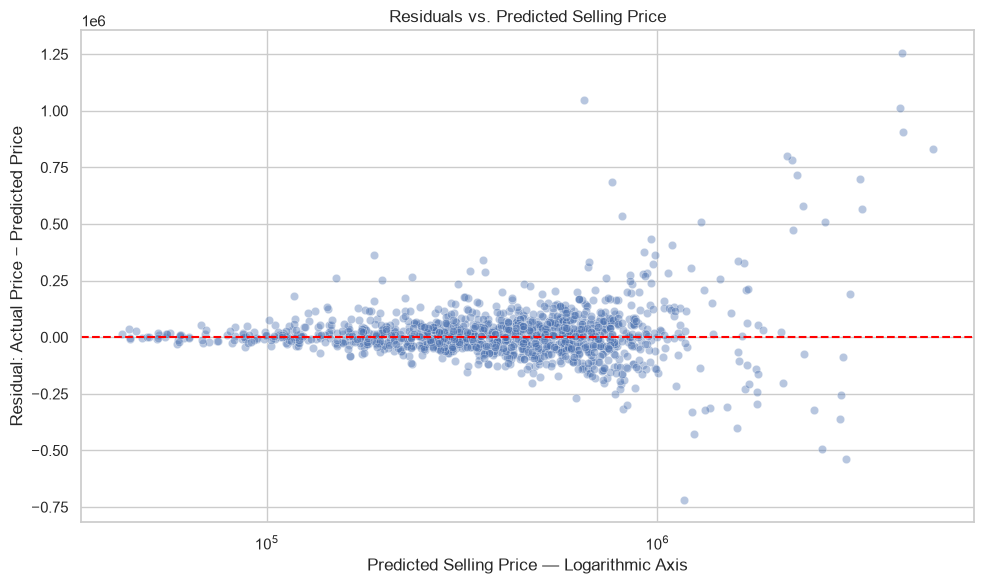

In [82]:
evaluation_df = X_test.copy()

evaluation_df["actual_price"] = actual_price
evaluation_df["predicted_price"] = pred_price

evaluation_df["residual"] = (
    evaluation_df["actual_price"]
    - evaluation_df["predicted_price"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["residual"].abs()
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=evaluation_df,
    x="predicted_price",
    y="residual",
    alpha=0.4
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xscale("log")

plt.title(
    "Residuals vs. Predicted Selling Price"
)

plt.xlabel(
    "Predicted Selling Price — Logarithmic Axis"
)

plt.ylabel(
    "Residual: Actual Price − Predicted Price"
)

plt.tight_layout()
plt.show()

In [83]:
display(evaluation_df.nlargest(10, "absolute_error")[[
    "brand", "year", "actual_price", "predicted_price", "absolute_error"
]])

,brand,year,actual_price,predicted_price,absolute_error
6444,Volvo,2019,5500000.0,4.244056e+06,1.255944e+06
1471,Mercedes-Benz,2011,1700000.0,6.503881e+05,1.049612e+06
3881,BMW,2019,5200000.0,4.189285e+06,1.010715e+06
124,Lexus,2019,5150000.0,4.245356e+06,9.046437e+05
4096,Audi,2019,5923000.0,5.093211e+06,8.297892e+05
3946,BMW,2016,2950000.0,2.148482e+06,8.015177e+05
1862,Audi,2014,3000000.0,2.215188e+06,7.848122e+05
5763,Chevrolet,2015,450000.0,1.168976e+06,7.189760e+05
5799,Audi,2018,3000000.0,2.283675e+06,7.163250e+05
4338,BMW,2018,4000000.0,3.301640e+06,6.983595e+05


## 9. Feature Importance

,feature,importance
0,numeric__year,0.481278
5,numeric__max_power,0.356463
4,numeric__engine,0.060834
3,numeric__mileage,0.024741
1,numeric__km_driven,0.024093
33,categorical__brand_Tata,0.012412
6,numeric__seats,0.009459
2,numeric__owner,0.006978
34,categorical__brand_Toyota,0.004542
11,categorical__brand_Chevrolet,0.003702


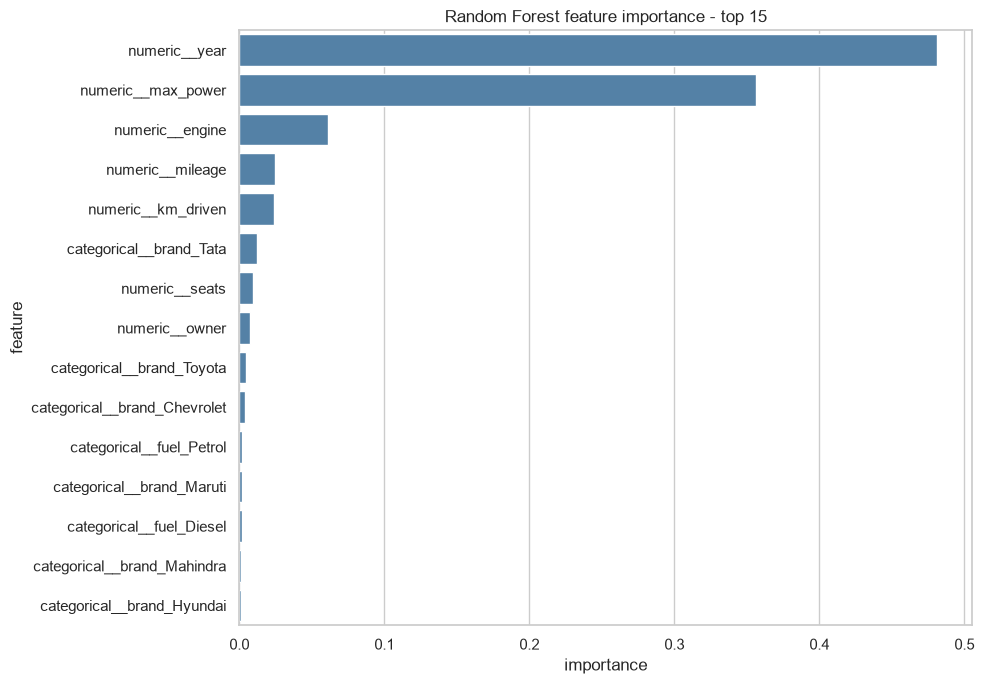

In [84]:
transformed_feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": final_pipeline.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(15))
plt.figure(figsize=(10, 7))
sns.barplot(data=rf_importance_df.head(15), x="importance", y="feature", color="steelblue")
plt.title("Random Forest feature importance - top 15")
plt.tight_layout(); plt.show()

,feature,importance,std
1,year,0.422637,0.010307
9,max_power,0.336227,0.006570
8,engine,0.097255,0.003840
0,brand,0.040134,0.001519
7,mileage,0.023825,0.001928
2,km_driven,0.015492,0.001746
10,seats,0.006703,0.000942
6,owner,0.003560,0.001122
3,fuel,0.003459,0.000720
5,transmission,0.001018,0.000416


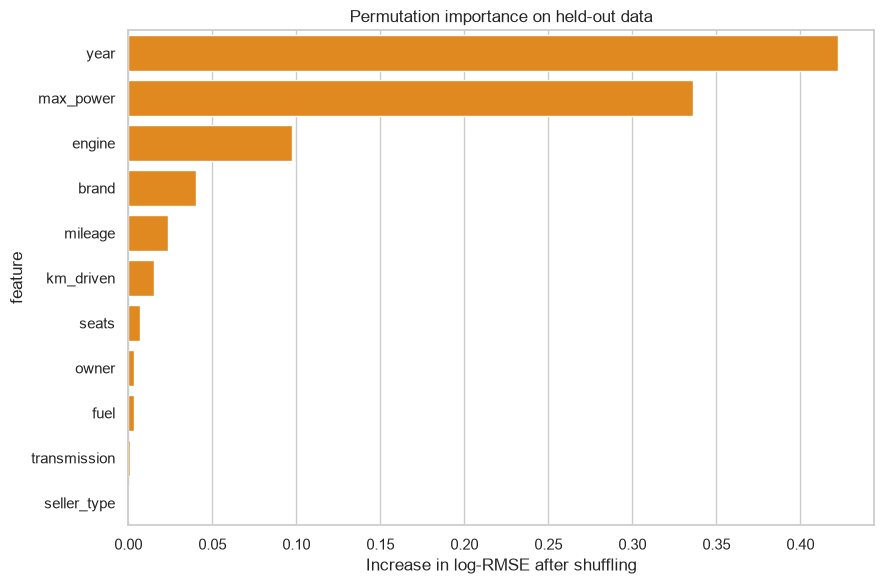

In [85]:
importance = permutation_importance(
    final_pipeline, X_test, y_test_price,
    scoring="neg_root_mean_squared_error",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": importance.importances_mean,
    "std": importance.importances_std,
}).sort_values("importance", ascending=False)
display(importance_df)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="darkorange")
plt.title("Permutation importance on held-out data")
plt.xlabel("Increase in log-RMSE after shuffling")
plt.tight_layout(); plt.show()

In [90]:
from pathlib import Path
import joblib

example_car = pd.DataFrame([{
    "year": 2018,
    "km_driven": 45_000,
    "owner": 1,
    "mileage": 20.0,
    "engine": 1197.0,
    "max_power": 82.0,
    "seats": 5.0,
    "brand": "Maruti",
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
}])
example_prediction = float(np.exp(final_pipeline.predict(example_car)[0]))
print(f"Example predicted selling price: {example_prediction:,.0f}")

MODEL_PATH = Path("../models/car_price_prediction_a1.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved complete preprocessing + model pipeline to {MODEL_PATH}")

Example predicted selling price: 518,066
Saved complete preprocessing + model pipeline to ../models/car_price_prediction_a1.joblib


In [86]:
top_features = importance_df.head(4)["feature"].tolist()
weak_features = importance_df.tail(3)["feature"].tolist()
best_cv = cv_results.iloc[0]
worst_non_dummy = cv_results.loc[cv_results["model"] != "Dummy median"].iloc[-1]
best_model_name = "Random Forest"

paragraph_1 = (
    f"After removing assignment-specified fuel and test-drive observations, parsing the "
    f"measurement fields, extracting brand, removing exact duplicates, and preserving missing "
    f"predictors for pipeline-based imputation, the data were divided into training and held-out "
    f"test partitions. The target was modeled as log(selling_price), which reduced its strong "
    f"right skew and limited the influence of a small number of extremely expensive cars. "
    f"Exploratory analysis suggested that model year, maximum power, engine size, "
    f"kilometers driven, transmission, and brand all contain pricing information, although these "
    f"relationships are associative and several features are correlated with one another."
)

paragraph_2 = (
    f"Five-fold cross-validation identified {best_model_name} as the strongest untuned candidate with mean log-RMSE "
    f"{best_cv['CV RMSE log']:.3f} and mean log-scale R2 {best_cv['CV R2']:.3f}. "
    f"Among the non-baseline candidates, {worst_non_dummy['model']} performed least well by "
    f"cross-validated RMSE. Following the class workflow, Random Forest was then tuned with GridSearchCV; "
    f"the best parameters were {grid_search.best_params_}. Tree ensembles can represent nonlinearities and interactions such "
    f"as the changing effect of age across brands and power levels, whereas linear models impose a "
    f"more restrictive additive relationship. The final held-out evaluation produced price-scale "
    f"MAE {test_metrics['MAE (price units)']:,.0f}, RMSE "
    f"{test_metrics['RMSE (price units)']:,.0f}, and R2 "
    f"{test_metrics['R2 (price units)']:.3f}. These test results were not used to select the model."
)

paragraph_3 = (
    f"Permutation analysis identified {', '.join(top_features)} as the strongest predictive "
    f"contributors for this fitted model, while {', '.join(weak_features)} contributed least. "
    f"Low marginal importance does not prove that a variable is intrinsically unimportant: another "
    f"correlated feature may supply similar information, and rare categories may have limited test "
    f"support. The largest errors are concentrated among unusual or high-priced vehicles, indicating "
    f"that future work should test grouped or time-aware validation, inspect potentially repeated "
    f"listings, tune the selected model in nested cross-validation, and report uncertainty intervals. "
    f"For deployment, the complete fitted pipeline is serialized so imputation, scaling, encoding, "
    f"and prediction remain identical between the notebook and web application."
)

display(Markdown(paragraph_1 + "\n\n" + paragraph_2 + "\n\n" + paragraph_3))

After removing assignment-specified fuel and test-drive observations, parsing the measurement fields, extracting brand, removing exact duplicates, and preserving missing predictors for pipeline-based imputation, the data were divided into training and held-out test partitions. The target was modeled as log(selling_price), which reduced its strong right skew and limited the influence of a small number of extremely expensive cars. Exploratory analysis suggested that model year, maximum power, engine size, kilometers driven, transmission, and brand all contain pricing information, although these relationships are associative and several features are correlated with one another.

Five-fold cross-validation identified Random Forest as the strongest untuned candidate with mean log-RMSE 0.230 and mean log-scale R2 0.906. Among the non-baseline candidates, Decision tree performed least well by cross-validated RMSE. Following the class workflow, Random Forest was then tuned with GridSearchCV; the best parameters were {'model__bootstrap': True, 'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}. Tree ensembles can represent nonlinearities and interactions such as the changing effect of age across brands and power levels, whereas linear models impose a more restrictive additive relationship. The final held-out evaluation produced price-scale MAE 71,693, RMSE 126,943, and R2 0.934. These test results were not used to select the model.

Permutation analysis identified year, max_power, engine, brand as the strongest predictive contributors for this fitted model, while fuel, transmission, seller_type contributed least. Low marginal importance does not prove that a variable is intrinsically unimportant: another correlated feature may supply similar information, and rare categories may have limited test support. The largest errors are concentrated among unusual or high-priced vehicles, indicating that future work should test grouped or time-aware validation, inspect potentially repeated listings, tune the selected model in nested cross-validation, and report uncertainty intervals. For deployment, the complete fitted pipeline is serialized so imputation, scaling, encoding, and prediction remain identical between the notebook and web application.